# The singular-value figures

What the truncation keeps and what it discards: the spectra along training, the
update/residual norms, the used rank, and the probe-set spectra and metrics for every
scan.

## How this works

```python
f = pf.make('<figure>')          # draws it, writes NOTHING
f.show(zoom=2)                   # magnified screen copy (the PDF keeps its page size)
f.ax(0).set_ylabel('...')        # edit the matplotlib objects however you like
f.fig.set_size_inches(5.5, 2.4)  # f.axes = the builder's layout, f.flat = every panel
f.save()                         # writes iclr_manuscript/figures_iclr/<group>/<figure>.pdf,
                                 # the PNG twin and the provenance sidecar -- exactly as
                                 # `python -m paper_assets` does
```

Two kinds of option:

* **the figure's own knobs** — what it draws (methods, scans, panels), its geometry
  (`fraction`, `aspect`), line weights, legend placement. `pf.info('<figure>')` lists them
  with their defaults.
* **the generic cosmetics**, on every figure: `figsize`, `xlabel`, `ylabel`, `title`,
  `xlim`, `ylim`, `xscale`, `yscale`, `legend`, `suptitle`, `grid`, `tick_labelsize`,
  `rc`. Each takes a value for all panels, a list by panel position, or a dict keyed by
  panel index — e.g. `ylabel={0: 'Validation loss'}`, `legend={'loc': 'lower left',
  'ncol': 6, 'fontsize': 5}`.

Pass either to `pf.make(...)` for a one-off, or **pin** it so the paper build draws it
that way too:

```python
pf.pin('headline_curves', methods='all', aspect=0.95)   # -> paper_assets/figure_overrides.yaml
pf.rebuild('headline_curves')                           # draw with the pinned options + save
pf.unpin('headline_curves')                             # back to the builder's default
```

Pinned options live in `analysis/paper_assets/figure_overrides.yaml`, which
`python -m paper_assets` reads, so a full rebuild reproduces your version instead of
reverting it. Nothing in this notebook writes until you call `save()` or `rebuild()`, so
re-running it top to bottom is safe.

**A note on size.** These are drawn at their true size on the page (a 0.32-linewidth
panel is 1.76 in wide, 7 pt type), so they look small inline; `show(zoom=...)` only
magnifies the screen copy. To judge the type size, look at the PNG twin under
`agent_lab/paper_assets/<group>/` after saving — it is written at the physical size.

In [1]:
%matplotlib inline
import os
import sys

# This notebook lives in analysis/notebooks/paper/, but every analysis path is
# relative to analysis/ (plots_v2/, tables/, ../experiment_results), so run from there
# with the helper modules in analysis/lib/ on the path.
_A = os.getcwd()
while not all(os.path.isdir(os.path.join(_A, d)) for d in ('lib', 'notebooks')):
    _A, _prev = os.path.dirname(_A), _A
    if _A == _prev:
        raise RuntimeError('analysis/ not found above ' + os.getcwd())
os.chdir(_A)
sys.path.insert(0, _A)
sys.path.insert(0, os.path.join(_A, 'lib'))

import paper_assets.notebook as pf

pf.figures('spectra')

,figure,group,module,knobs,pinned,what
0,mnist_lr_vs_ce,spectra,spectra,"alpha_range, annot_fontsize, aspect, band_alph...",-,"F9, App. I: MNIST label regression against cro..."
1,online_mechanism,spectra,spectra,"aspect, discard_floor, extra_h, fraction, lege...",-,"F9, App. O: kept / discarded batch residual, t..."
2,online_norms,spectra,spectra,"aspect, band, extra_h, fraction, legend_kw, le...",-,"F9, App. O: applied update norm and batch resi..."
3,online_spectra,spectra,spectra,"annotate_steps, aspect, cmap, extra_h, fractio...",-,"F9, App. O: the online per-batch spectrum over..."
4,online_utr,spectra,spectra,"annotate_steps, aspect, cmap, extra_h, fractio...",-,"F9, App. O: |u_i.r| / ||U^T r|| over training ..."
5,probe_energy,spectra,spectra,"annotate_steps, aspect, cmap, extra_h, fractio...",-,"F9, App. O: cumulative PROBE residual against ..."
6,probe_metrics,spectra,spectra,"aspect, band, cond_pad, extra_h, fraction, leg...",-,"F9, App. O: effective rank, condition number a..."
7,probe_metrics_all,spectra,spectra,"aspect, band, cond_pad, extra_h, fraction, leg...",-,"F9, App. O: the same probe metrics plus the re..."
8,probe_norms,spectra,spectra,"aspect, band, cond_pad, extra_h, fraction, leg...",-,"F9, App. O: distance from initialisation and p..."
9,probe_spectra,spectra,spectra,"annotate_steps, aspect, cmap, extra_h, fractio...",-,"F9, App. O: offline float64 probe spectra alon..."


## `mnist_lr_vs_ce`

F9, App. I: MNIST label regression against cross-entropy -- same model, same B, same splits, two spectra

Its own knobs:

* `alpha_range` — default `[0.3, 1.0]`
* `annot_fontsize` — default `6.0`
* `aspect` — default `0.85`
* `band_alpha` — default `0.2`
* `extra_h` — default `0.3`
* `fraction` — default `0.32`
* `legend_kw` — default `{}`
* `legend_ncol` — default `3`
* `lw` — default `1.1`
* `marks` — default `[0.0, 0.02, 0.1, 0.5, 1.0]`
* `ncol` — default `3`
* `rank_headroom` — default `1.9`
* `scan_lw` — default `1.3`
* `scans` — default `['mnist_scan_labelRegression', 'mnist_scan_ce']`
* `sharex` — default `False`
* `sharey` — default `False`
* `show_legend` — default `True`
* `smooth` — default `60`


Loaded 75 runs from ../experiment_results/_cache/toy_1d_scan_diag.slim.pkl (slim cache)
Loaded 75 runs from ../experiment_results/_cache/polynomial_scan_diag.slim.pkl (slim cache)
Loaded 70 runs from ../experiment_results/_cache/mnist_scan_labelRegression_diag.slim.pkl (slim cache)


Loaded 70 runs from ../experiment_results/_cache/mnist_scan_ce_diag.slim.pkl (slim cache)
Loaded 55 runs from ../experiment_results/_cache/cifar10_resnet_scan_labelRegression_diag.slim.pkl (slim cache)


Loaded 60 runs from ../experiment_results/_cache/cifar10_resnet_ce_scan_diag.slim.pkl (slim cache)
Loaded 25 runs from ../experiment_results/_cache/exp_nanogpt_speedrun_diag.slim.pkl (slim cache)


Loaded 1770 runs from ../experiment_results/_cache/toy_1d_scan.slim.pkl (slim cache)
Loaded 1630 runs from ../experiment_results/_cache/polynomial_scan.slim.pkl (slim cache)


Loaded 1360 runs from ../experiment_results/_cache/mnist_scan_labelRegression.slim.pkl (slim cache)
Loaded 1610 runs from ../experiment_results/_cache/mnist_scan_ce.slim.pkl (slim cache)


Loaded 600 runs from ../experiment_results/_cache/cifar10_resnet_scan_labelRegression.slim.pkl (slim cache)
Loaded 785 runs from ../experiment_results/_cache/cifar10_resnet_ce_scan.slim.pkl (slim cache)
Loaded 140 runs from ../experiment_results/_cache/exp_nanogpt_speedrun.slim.pkl (slim cache)


7 diag passes (35 Sven runs), 4 scans with cached probe spectra
rank law min(k, rtol-rank) == num_nonzero_svs on 49040 logged steps: True


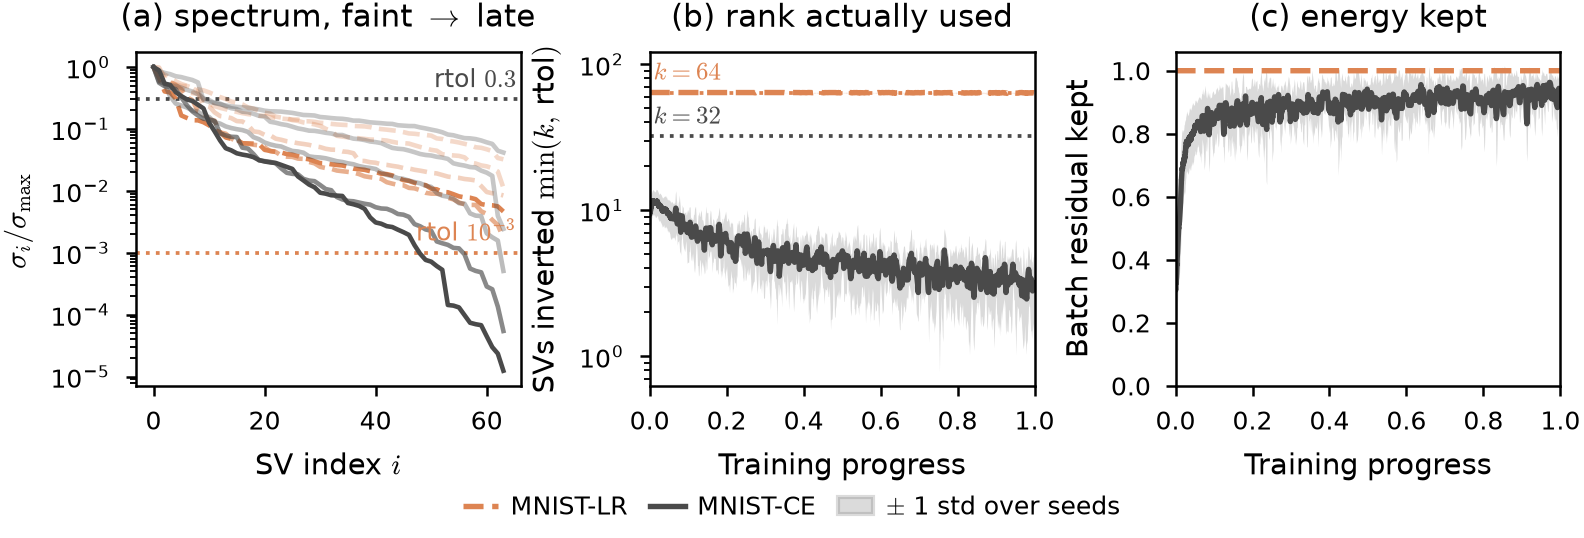

mnist_lr_vs_ce: 5.28 x 1.80 in on the page (shown at 2x)


In [2]:
f = pf.make('mnist_lr_vs_ce')
f.show(zoom=2)

In [3]:
# --- edit mnist_lr_vs_ce -------------------------------------------------------
# its own knobs: alpha_range, annot_fontsize, aspect, band_alpha, extra_h, fraction, legend_kw, legend_ncol, lw, marks, ncol, rank_headroom, scan_lw, scans, sharex, sharey, show_legend, smooth
# f = pf.make('mnist_lr_vs_ce', alpha_range=[0.3, 1.0], annot_fontsize=6.0, aspect=0.85)
# f = pf.make('mnist_lr_vs_ce', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('mnist_lr_vs_ce', aspect=0.95)              # ... and make the CLI agree

## `online_mechanism`

F9, App. O: kept / discarded batch residual, the used rank, and its seed spread on the scan where it is widest

Its own knobs:

* `aspect` — default `0.78`
* `discard_floor` — default `1e-08`
* `extra_h` — default `0.26`
* `fraction` — default `0.49`
* `legend_kw` — default `{}`
* `legend_ncol` — default `7`
* `ncol` — default `2`
* `scan_lw` — default `1.3`
* `scans` — default `[]`
* `seed_legend_kw` — default `{'ncol': 2, 'handlelength': 1.0, 'labelspacing': 0.15, 'fontsize': 6.5}`
* `seed_lw` — default `1.0`
* `seed_smooth` — default `25`
* `sharex` — default `False`
* `sharey` — default `False`
* `show_legend` — default `True`
* `smooth` — default `60`
* `spread_scan` — default `''`


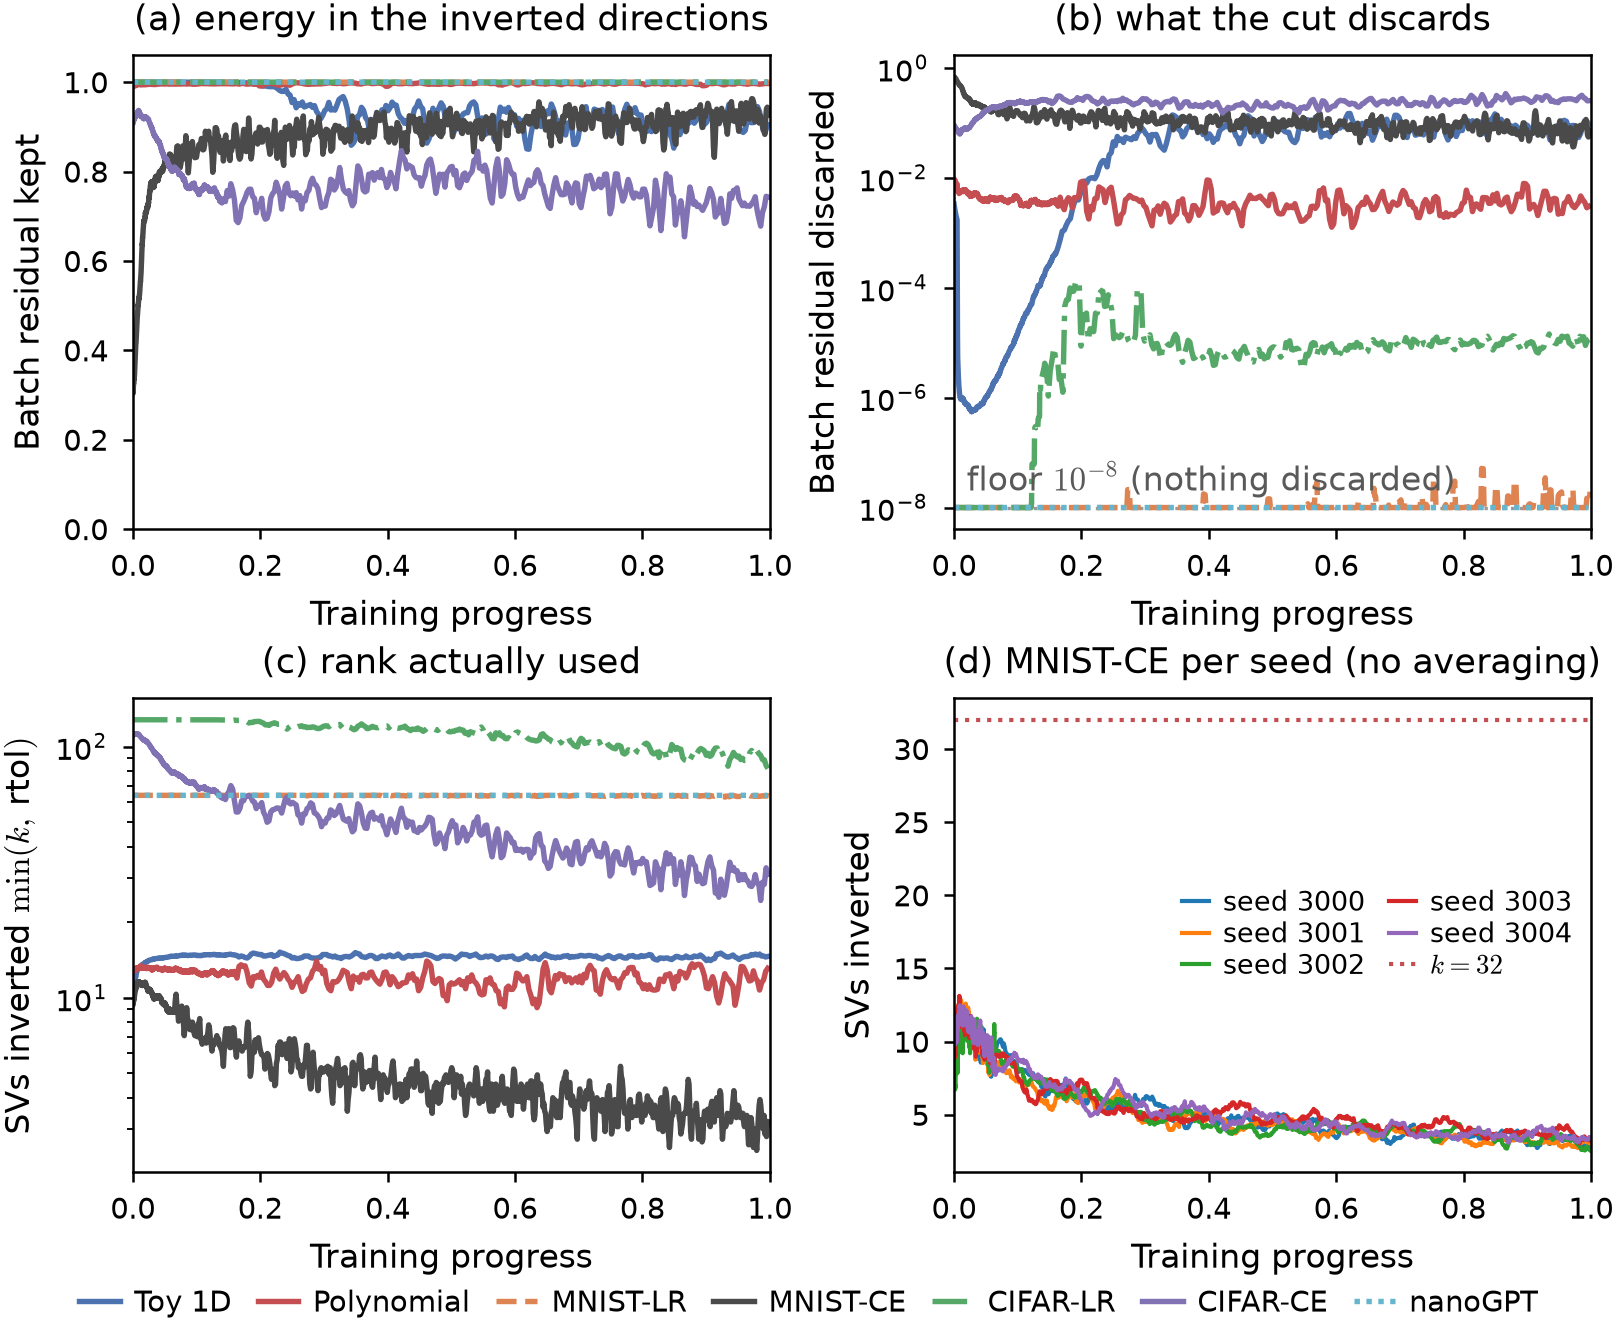

online_mechanism: 5.39 x 4.46 in on the page (shown at 2x)


In [4]:
f = pf.make('online_mechanism')
f.show(zoom=2)

In [5]:
# --- edit online_mechanism -------------------------------------------------------
# its own knobs: aspect, discard_floor, extra_h, fraction, legend_kw, legend_ncol, ncol, scan_lw, scans, seed_legend_kw, seed_lw, seed_smooth, sharex, sharey, show_legend, smooth, spread_scan
# f = pf.make('online_mechanism', aspect=0.78, discard_floor=1e-08, extra_h=0.26)
# f = pf.make('online_mechanism', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('online_mechanism', aspect=0.95)              # ... and make the CLI agree

## `online_norms`

F9, App. O: applied update norm and batch residual norm, one panel per scan

Its own knobs:

* `aspect` — default `0.95`
* `band` — default `True`
* `extra_h` — default `0.0`
* `fraction` — default `0.25`
* `legend_kw` — default `{}`
* `legend_lw` — default `1.4`
* `legend_ncol` — default `3`
* `ncol` — default `4`
* `scans` — default `[]`
* `sharex` — default `False`
* `sharey` — default `False`
* `short_titles` — default `True`
* `show_legend` — default `True`
* `smooth` — default `25`
* `title_lines` — default `2`


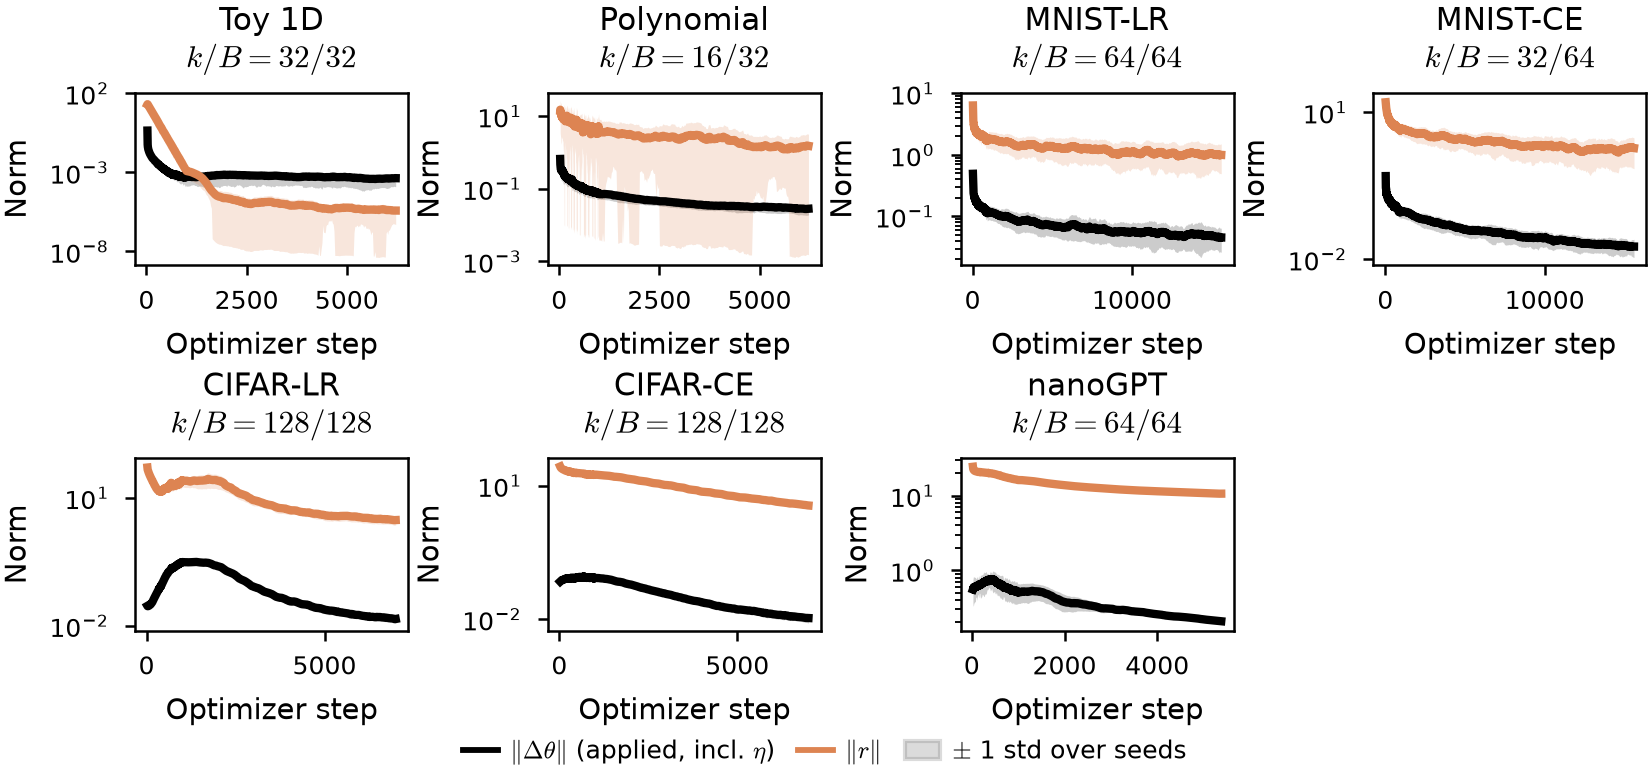

online_norms: 5.50 x 2.61 in on the page (shown at 2x)


In [6]:
f = pf.make('online_norms')
f.show(zoom=2)

In [7]:
# --- edit online_norms -------------------------------------------------------
# its own knobs: aspect, band, extra_h, fraction, legend_kw, legend_lw, legend_ncol, ncol, scans, sharex, sharey, short_titles, show_legend, smooth, title_lines
# f = pf.make('online_norms', aspect=0.95, band=True, extra_h=0.0)
# f = pf.make('online_norms', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('online_norms', aspect=0.95)              # ... and make the CLI agree

## `online_spectra`

F9, App. O: the online per-batch spectrum over training, one panel per scan

Its own knobs:

* `annotate_steps` — default `True`
* `aspect` — default `0.95`
* `cmap` — default `'plasma'`
* `extra_h` — default `0.0`
* `fraction` — default `0.25`
* `k_loc` — default `'top'`
* `limit` — default `40`
* `lw` — default `0.6`
* `ncol` — default `4`
* `scans` — default `[]`
* `sharex` — default `False`
* `sharey` — default `False`
* `short_titles` — default `True`
* `show_k` — default `True`
* `show_noise` — default `True`
* `show_rtol` — default `True`
* `spectrum_headroom` — default `[4.0, 6.0]`
* `step_label_loc` — default `'lower left'`
* `title_lines` — default `2`


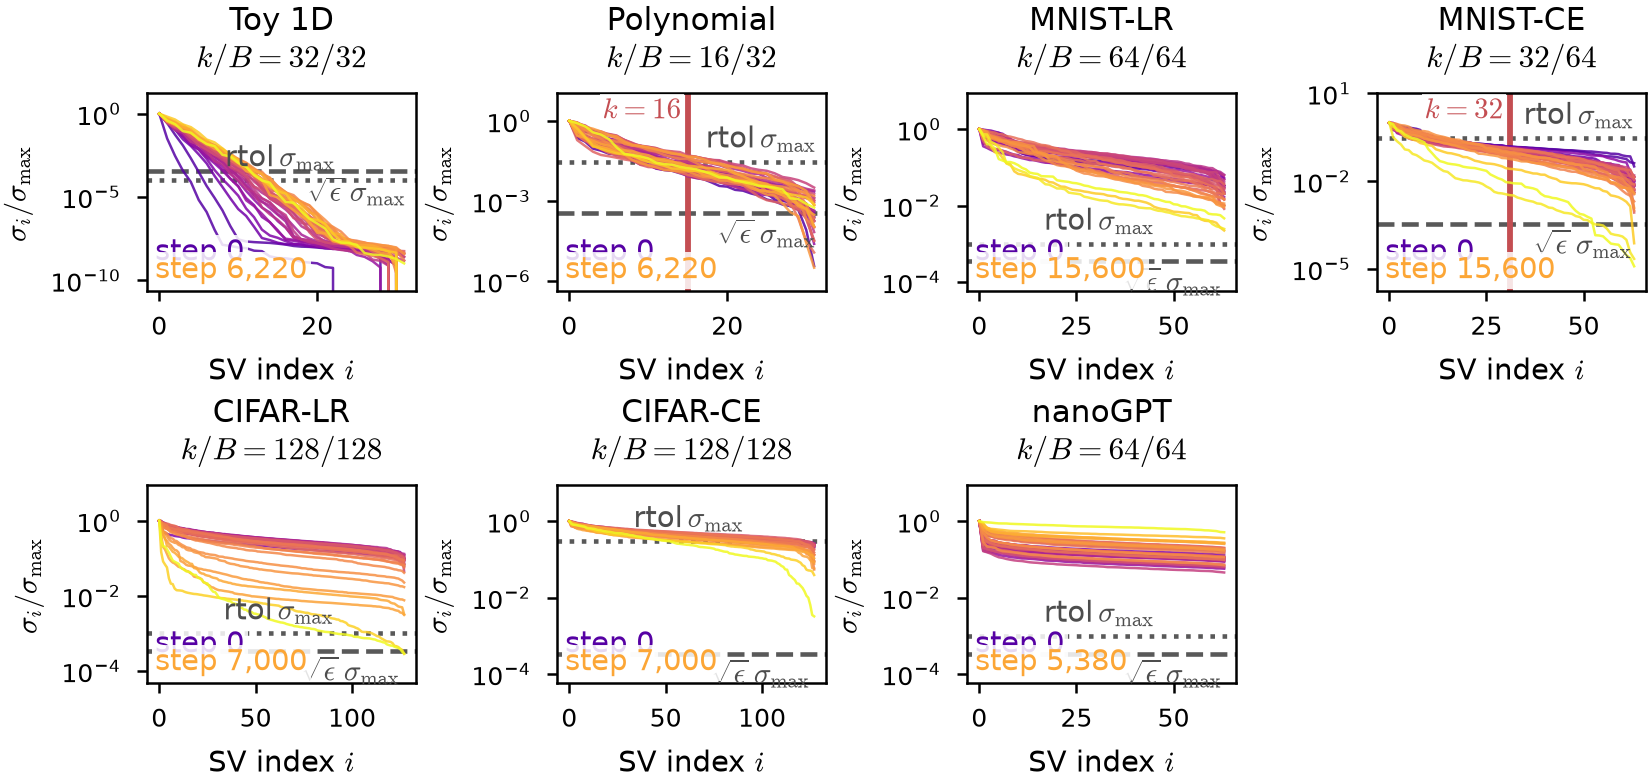

online_spectra: 5.50 x 2.61 in on the page (shown at 2x)


In [8]:
f = pf.make('online_spectra')
f.show(zoom=2)

In [9]:
# --- edit online_spectra -------------------------------------------------------
# its own knobs: annotate_steps, aspect, cmap, extra_h, fraction, k_loc, limit, lw, ncol, scans, sharex, sharey, short_titles, show_k, show_noise, show_rtol, spectrum_headroom, step_label_loc, title_lines
# f = pf.make('online_spectra', annotate_steps=True, aspect=0.95, cmap='plasma')
# f = pf.make('online_spectra', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('online_spectra', aspect=0.95)              # ... and make the CLI agree

## `online_utr`

F9, App. O: |u_i.r| / ||U^T r|| over training -- where the residual sits

Its own knobs:

* `annotate_steps` — default `True`
* `aspect` — default `0.95`
* `cmap` — default `'plasma'`
* `extra_h` — default `0.0`
* `fraction` — default `0.25`
* `limit` — default `40`
* `lw` — default `0.6`
* `ncol` — default `4`
* `scans` — default `[]`
* `sharex` — default `False`
* `sharey` — default `False`
* `short_titles` — default `True`
* `show_k` — default `True`
* `spectrum_headroom` — default `[3.0, 1.5]`
* `step_label_loc` — default `'auto'`
* `title_lines` — default `2`


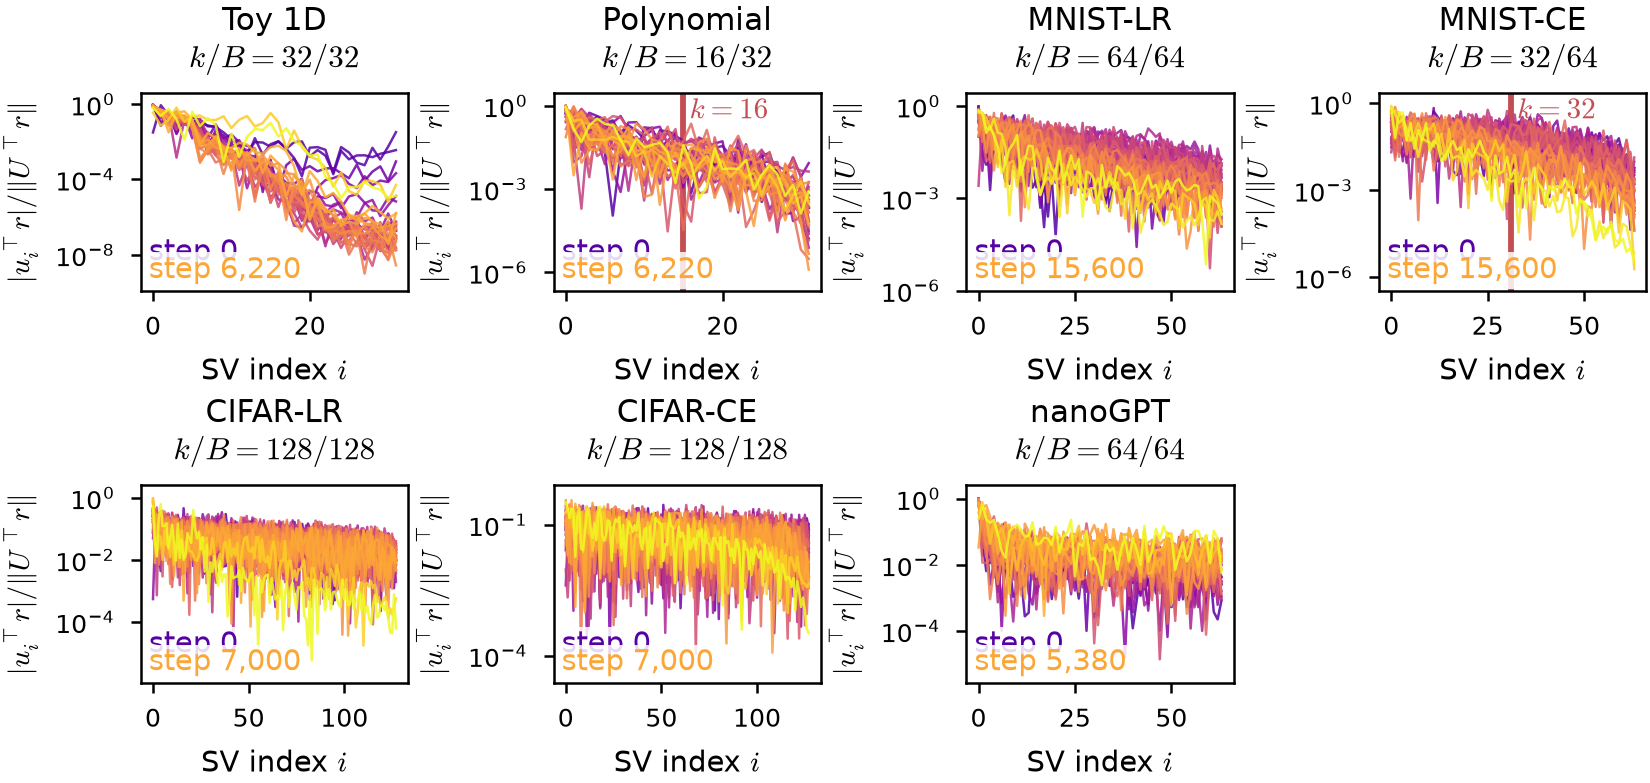

online_utr: 5.50 x 2.61 in on the page (shown at 2x)


In [10]:
f = pf.make('online_utr')
f.show(zoom=2)

In [11]:
# --- edit online_utr -------------------------------------------------------
# its own knobs: annotate_steps, aspect, cmap, extra_h, fraction, limit, lw, ncol, scans, sharex, sharey, short_titles, show_k, spectrum_headroom, step_label_loc, title_lines
# f = pf.make('online_utr', annotate_steps=True, aspect=0.95, cmap='plasma')
# f = pf.make('online_utr', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('online_utr', aspect=0.95)              # ... and make the CLI agree

## `probe_energy`

F9, App. O: cumulative PROBE residual against directions kept, with k

Its own knobs:

* `annotate_steps` — default `True`
* `aspect` — default `1.0`
* `cmap` — default `'plasma'`
* `extra_h` — default `0.0`
* `fraction` — default `0.25`
* `limit` — default `7`
* `ncol` — default `4`
* `scans` — default `[]`
* `sharex` — default `False`
* `sharey` — default `False`
* `show_k` — default `True`
* `step_label_fallback` — default `'lower right'`
* `step_label_loc` — default `'auto'`


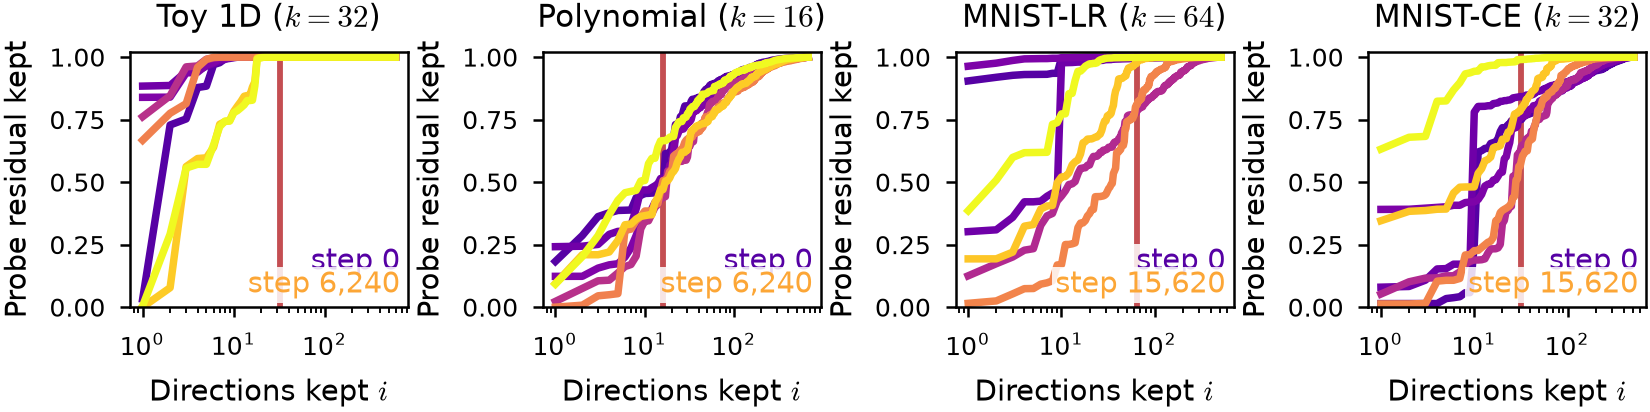

probe_energy: 5.50 x 1.38 in on the page (shown at 2x)


In [12]:
f = pf.make('probe_energy')
f.show(zoom=2)

In [13]:
# --- edit probe_energy -------------------------------------------------------
# its own knobs: annotate_steps, aspect, cmap, extra_h, fraction, limit, ncol, scans, sharex, sharey, show_k, step_label_fallback, step_label_loc
# f = pf.make('probe_energy', annotate_steps=True, aspect=1.0, cmap='plasma')
# f = pf.make('probe_energy', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('probe_energy', aspect=0.95)              # ... and make the CLI agree

## `probe_metrics`

F9, App. O: effective rank, condition number and sigma_B/sigma_1 along the trajectories of two scans

Its own knobs:

* `aspect` — default `0.88`
* `band` — default `True`
* `cond_pad` — default `5.0`
* `extra_h` — default `0.26`
* `fraction` — default `0.32`
* `legend_kw` — default `{}`
* `legend_ncol` — default `6`
* `marker` — default `'.'`
* `metrics` — default `['eff_rank', 'cond', 'sigma_B_over_1']`
* `ncol` — default `0`
* `scans` — default `['polynomial_scan', 'mnist_scan_ce']`
* `sharex` — default `False`
* `sharey` — default `False`
* `show_legend` — default `True`


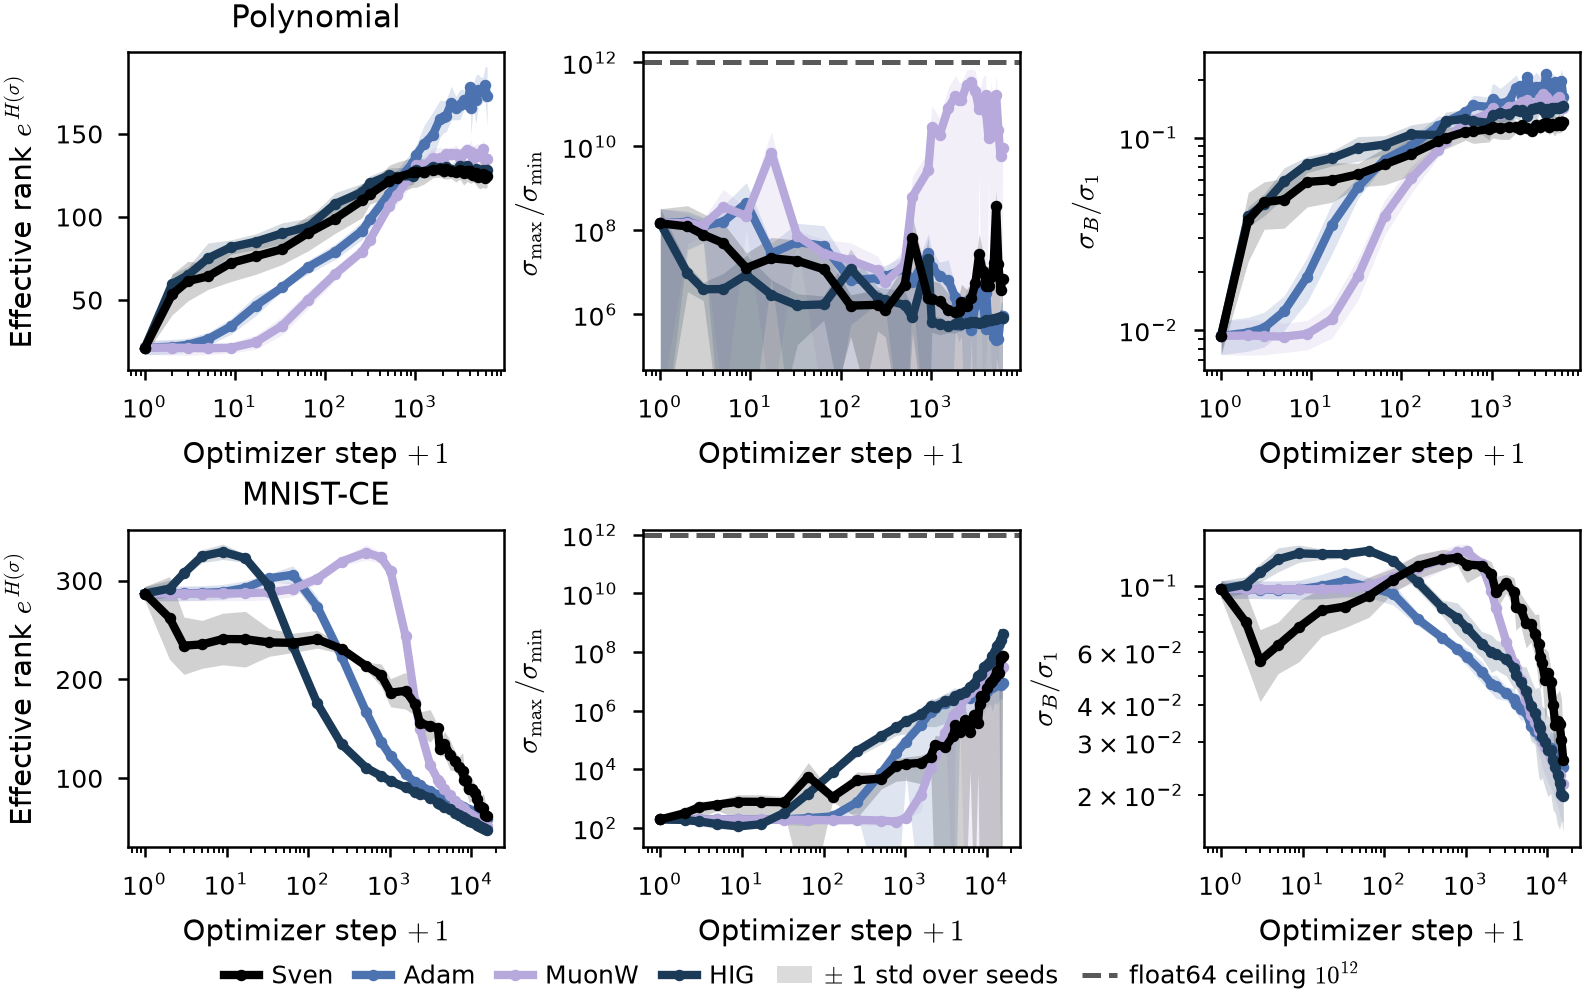

probe_metrics: 5.28 x 3.36 in on the page (shown at 2x)


In [14]:
f = pf.make('probe_metrics')
f.show(zoom=2)

In [15]:
# --- edit probe_metrics -------------------------------------------------------
# its own knobs: aspect, band, cond_pad, extra_h, fraction, legend_kw, legend_ncol, marker, metrics, ncol, scans, sharex, sharey, show_legend
# f = pf.make('probe_metrics', aspect=0.88, band=True, cond_pad=5.0)
# f = pf.make('probe_metrics', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('probe_metrics', aspect=0.95)              # ... and make the CLI agree

## `probe_metrics_all`

F9, App. O: the same probe metrics plus the resolved rank, every cached scan

Its own knobs:

* `aspect` — default `0.92`
* `band` — default `True`
* `cond_pad` — default `5.0`
* `extra_h` — default `0.24`
* `fraction` — default `0.25`
* `legend_kw` — default `{}`
* `legend_ncol` — default `6`
* `marker` — default `'.'`
* `metrics` — default `['rank', 'eff_rank', 'cond', 'sigma_B_over_1']`
* `ncol` — default `0`
* `scans` — default `[]`
* `sharex` — default `False`
* `sharey` — default `False`
* `show_legend` — default `True`


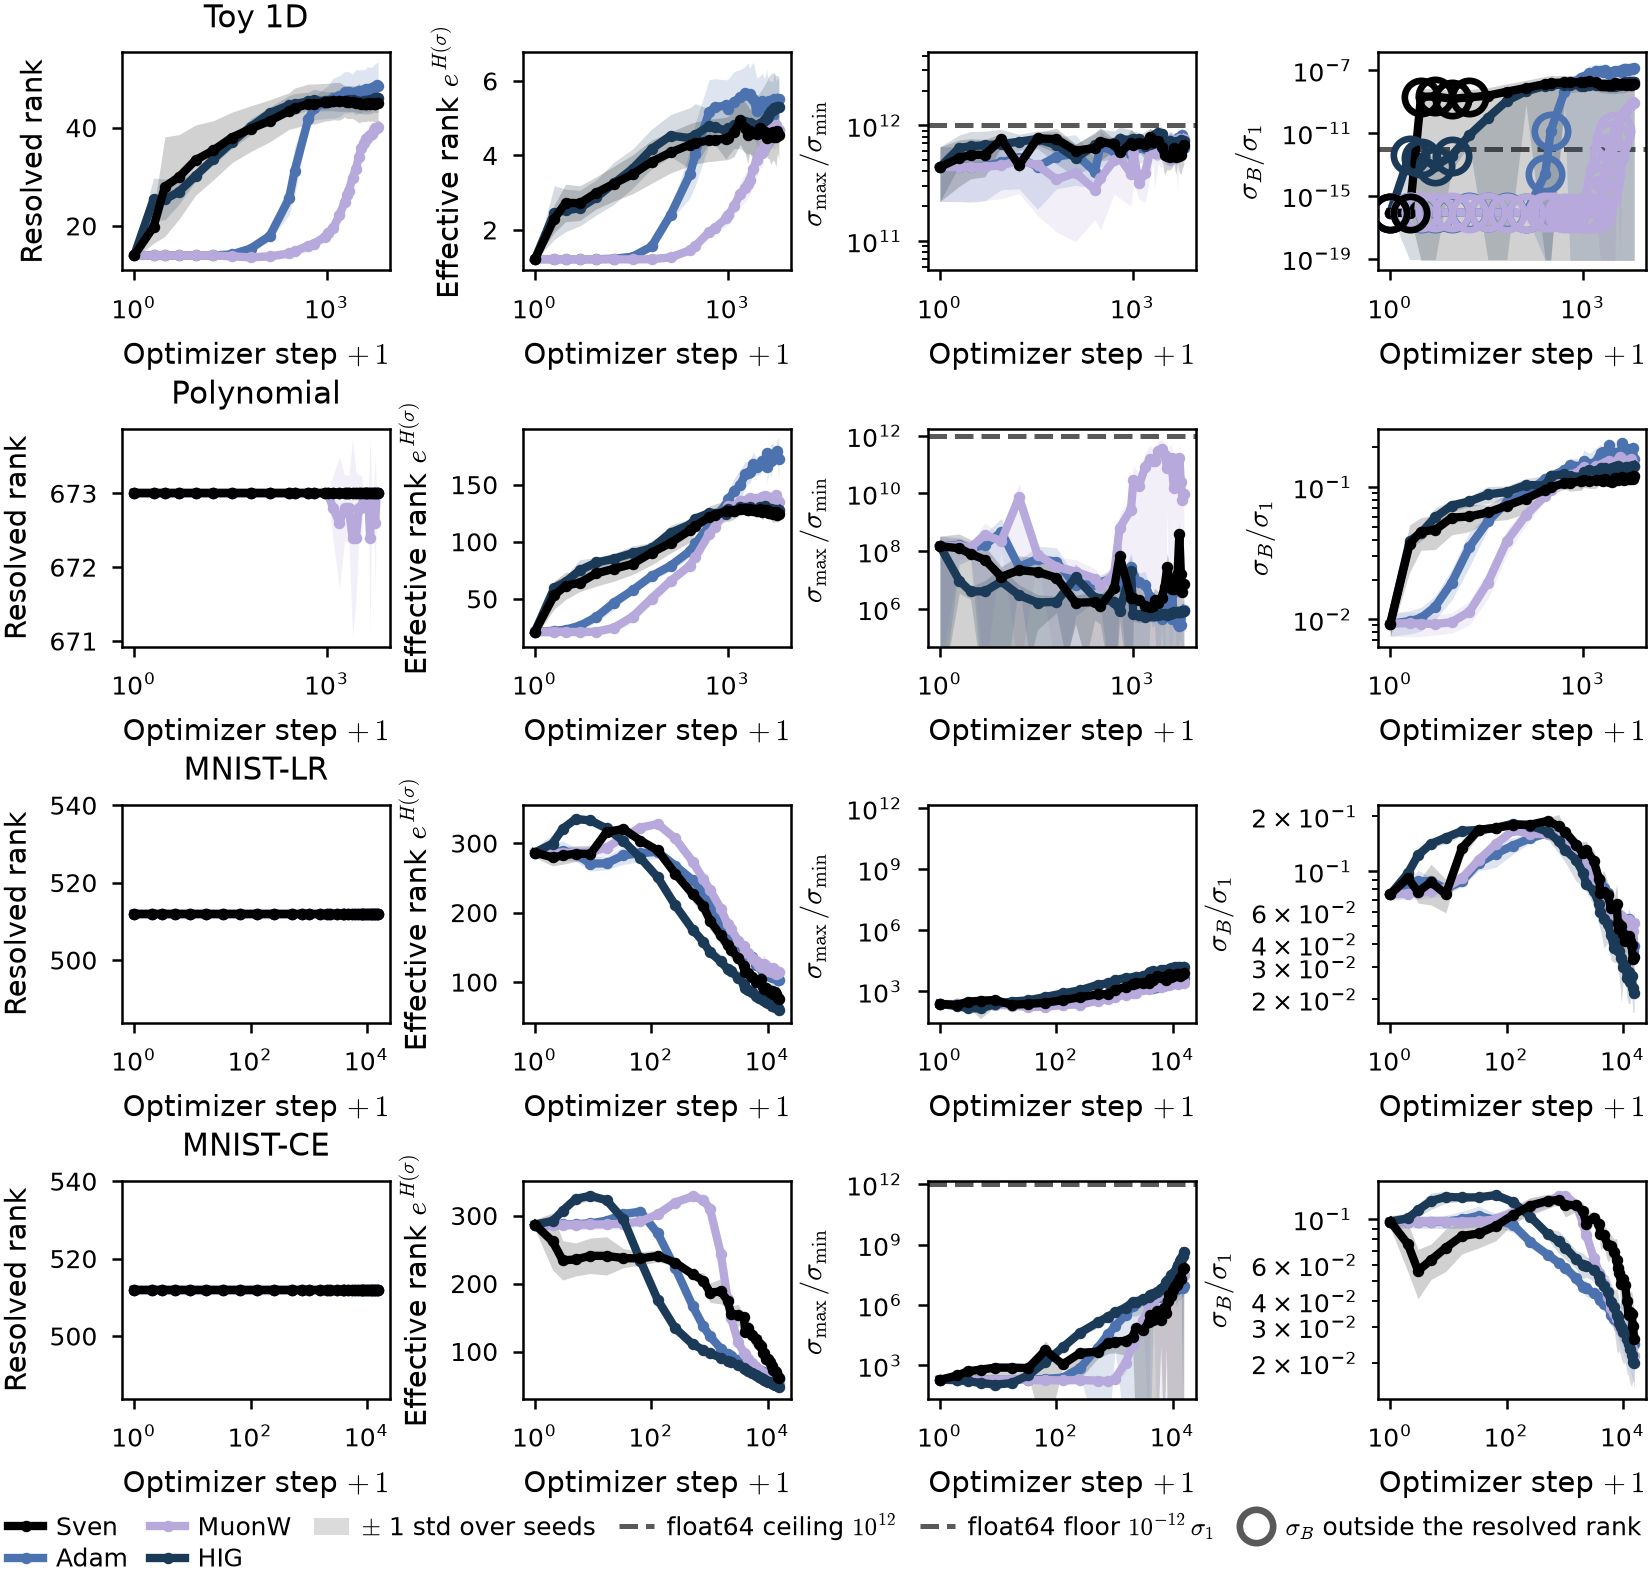

probe_metrics_all: 5.50 x 5.30 in on the page (shown at 2x)


In [16]:
f = pf.make('probe_metrics_all')
f.show(zoom=2)

In [17]:
# --- edit probe_metrics_all -------------------------------------------------------
# its own knobs: aspect, band, cond_pad, extra_h, fraction, legend_kw, legend_ncol, marker, metrics, ncol, scans, sharex, sharey, show_legend
# f = pf.make('probe_metrics_all', aspect=0.92, band=True, cond_pad=5.0)
# f = pf.make('probe_metrics_all', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('probe_metrics_all', aspect=0.95)              # ... and make the CLI agree

## `probe_norms`

F9, App. O: distance from initialisation and parameter norm (C12), scans across the columns

Its own knobs:

* `aspect` — default `0.92`
* `band` — default `True`
* `cond_pad` — default `5.0`
* `extra_h` — default `0.24`
* `fraction` — default `0.25`
* `legend_kw` — default `{}`
* `legend_ncol` — default `5`
* `logy` — default `False`
* `marker` — default `'.'`
* `metrics` — default `['dist_init', 'param_norm']`
* `ncol` — default `0`
* `scans` — default `[]`
* `sharex` — default `False`
* `sharey` — default `False`
* `show_legend` — default `True`


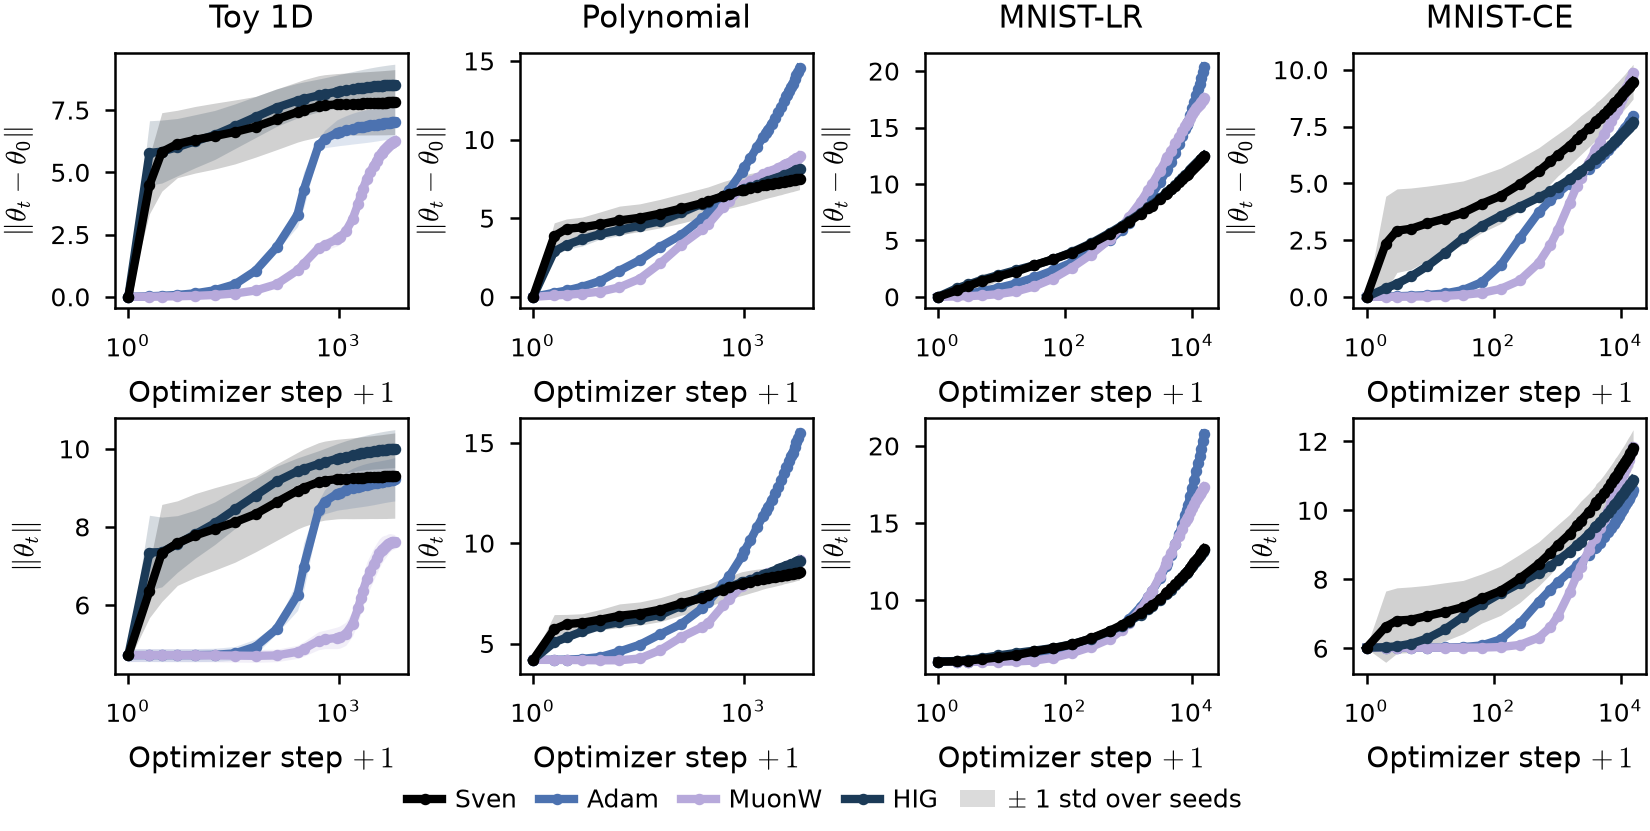

probe_norms: 5.50 x 2.77 in on the page (shown at 2x)


In [18]:
f = pf.make('probe_norms')
f.show(zoom=2)

In [19]:
# --- edit probe_norms -------------------------------------------------------
# its own knobs: aspect, band, cond_pad, extra_h, fraction, legend_kw, legend_ncol, logy, marker, metrics, ncol, scans, sharex, sharey, show_legend
# f = pf.make('probe_norms', aspect=0.92, band=True, cond_pad=5.0)
# f = pf.make('probe_norms', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('probe_norms', aspect=0.95)              # ... and make the CLI agree

## `probe_spectra`

F9, App. O: offline float64 probe spectra along each optimizer, one scan and one named seed

Its own knobs:

* `annotate_steps` — default `True`
* `aspect` — default `0.82`
* `cmap` — default `'plasma'`
* `extra_h` — default `0.0`
* `fraction` — default `0.49`
* `k_lw` — default `1.1`
* `limit` — default `12`
* `lw` — default `1.3`
* `ncol` — default `2`
* `scan` — default `''`
* `scan_seed_title` — default `True`
* `sharex` — default `False`
* `sharey` — default `True`
* `show_k` — default `True`
* `step_label_loc` — default `'auto'`


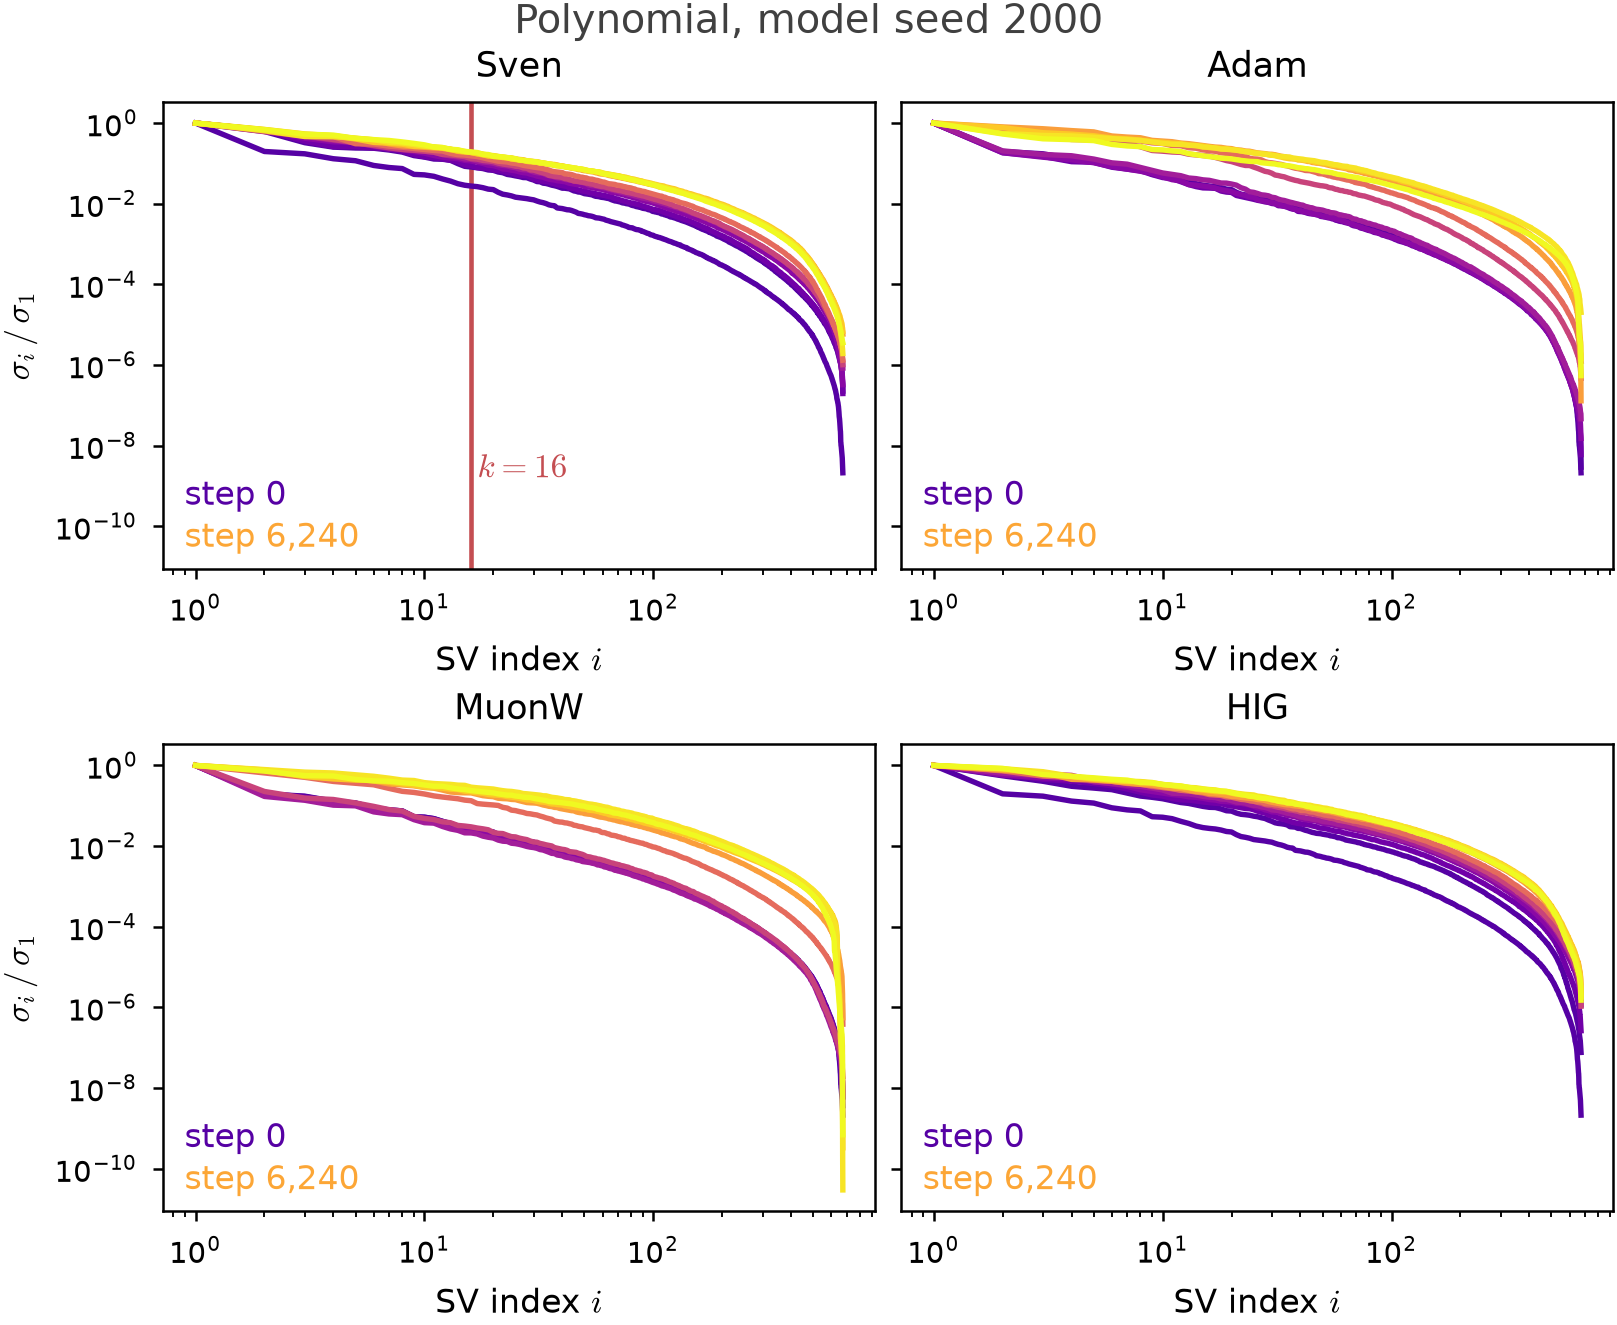

probe_spectra: 5.39 x 4.42 in on the page (shown at 2x)


In [20]:
f = pf.make('probe_spectra')
f.show(zoom=2)

In [21]:
# --- edit probe_spectra -------------------------------------------------------
# its own knobs: annotate_steps, aspect, cmap, extra_h, fraction, k_lw, limit, lw, ncol, scan, scan_seed_title, sharex, sharey, show_k, step_label_loc
# f = pf.make('probe_spectra', annotate_steps=True, aspect=0.82, cmap='plasma')
# f = pf.make('probe_spectra', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('probe_spectra', aspect=0.95)              # ... and make the CLI agree

## `probe_spectra_all`

F9, App. O: the probe-spectrum figure over every cached scan x optimizer

Its own knobs:

* `annotate_steps` — default `True`
* `aspect` — default `0.92`
* `cmap` — default `'plasma'`
* `extra_h` — default `0.0`
* `fraction` — default `0.25`
* `k_lw` — default `1.0`
* `limit` — default `12`
* `lw` — default `1.3`
* `ncol` — default `0`
* `scans` — default `[]`
* `sharex` — default `False`
* `sharey` — default `False`
* `show_k` — default `True`
* `step_label_loc` — default `'lower left'`


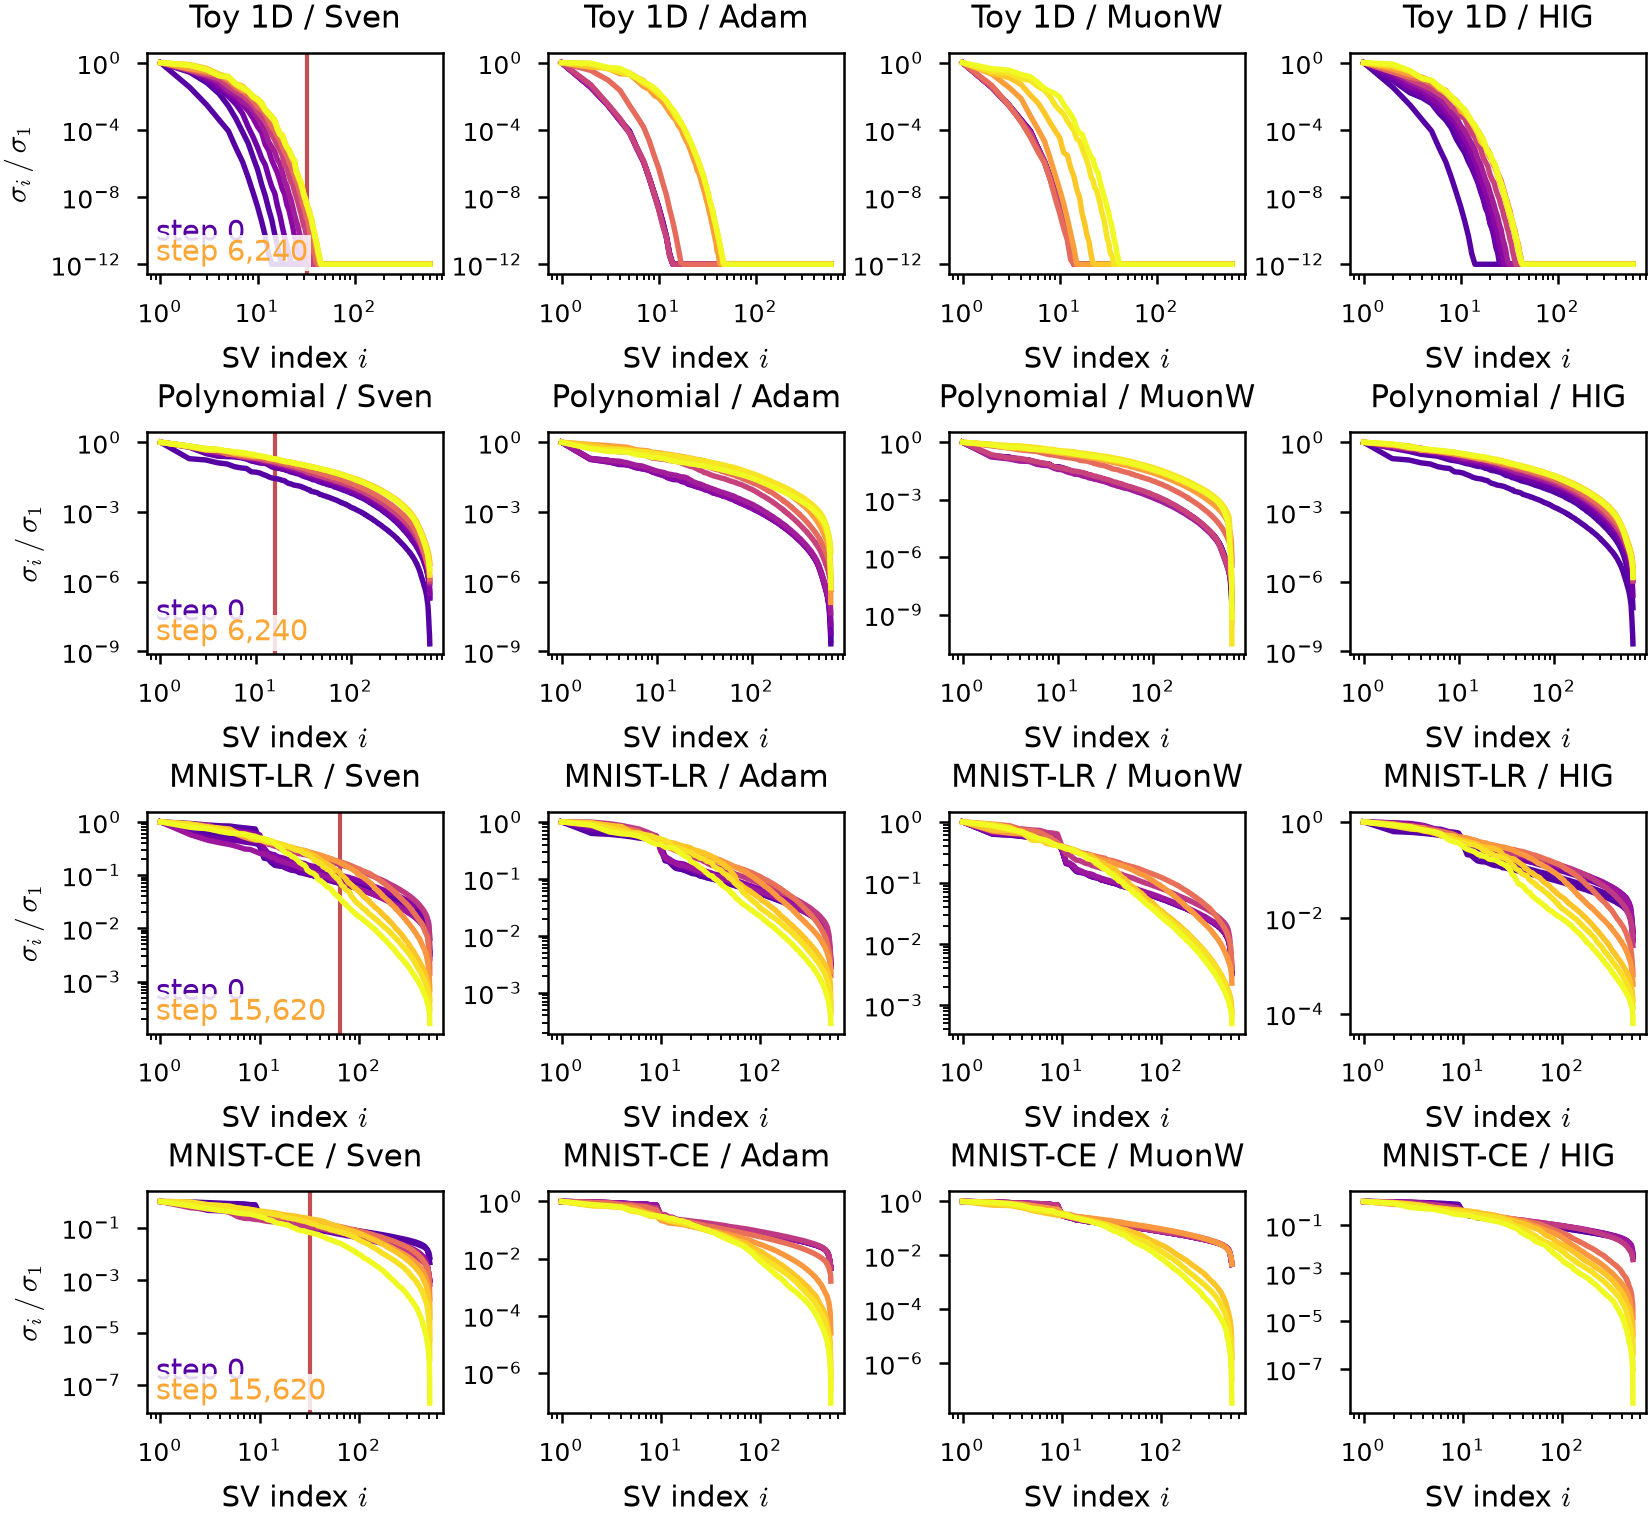

probe_spectra_all: 5.50 x 5.06 in on the page (shown at 2x)


In [22]:
f = pf.make('probe_spectra_all')
f.show(zoom=2)

In [23]:
# --- edit probe_spectra_all -------------------------------------------------------
# its own knobs: annotate_steps, aspect, cmap, extra_h, fraction, k_lw, limit, lw, ncol, scans, sharex, sharey, show_k, step_label_loc
# f = pf.make('probe_spectra_all', annotate_steps=True, aspect=0.92, cmap='plasma')
# f = pf.make('probe_spectra_all', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('probe_spectra_all', aspect=0.95)              # ... and make the CLI agree

## `spectrum_truncation`

F2, main 4.2: (a) the polynomial batch spectrum with the k / rtol / round-off cuts, (b) what the cut discards, (c) the rank inverted

Its own knobs:

* `annotate_steps` — default `True`
* `aspect` — default `1.0`
* `cmap` — default `'plasma'`
* `discard_floor` — default `1e-08`
* `extra_h` — default `0.3`
* `fraction` — default `0.32`
* `legend_kw` — default `{}`
* `legend_ncol` — default `4`
* `limit` — default `40`
* `lw` — default `0.55`
* `ncol` — default `3`
* `scan_lw` — default `1.3`
* `scans` — default `[]`
* `sharex` — default `False`
* `sharey` — default `False`
* `show_k` — default `True`
* `show_legend` — default `True`
* `show_noise` — default `True`
* `show_rtol` — default `True`
* `smooth` — default `60`
* `spectrum_headroom` — default `[6.0, 1.4]`
* `spectrum_scan` — default `'polynomial_scan'`


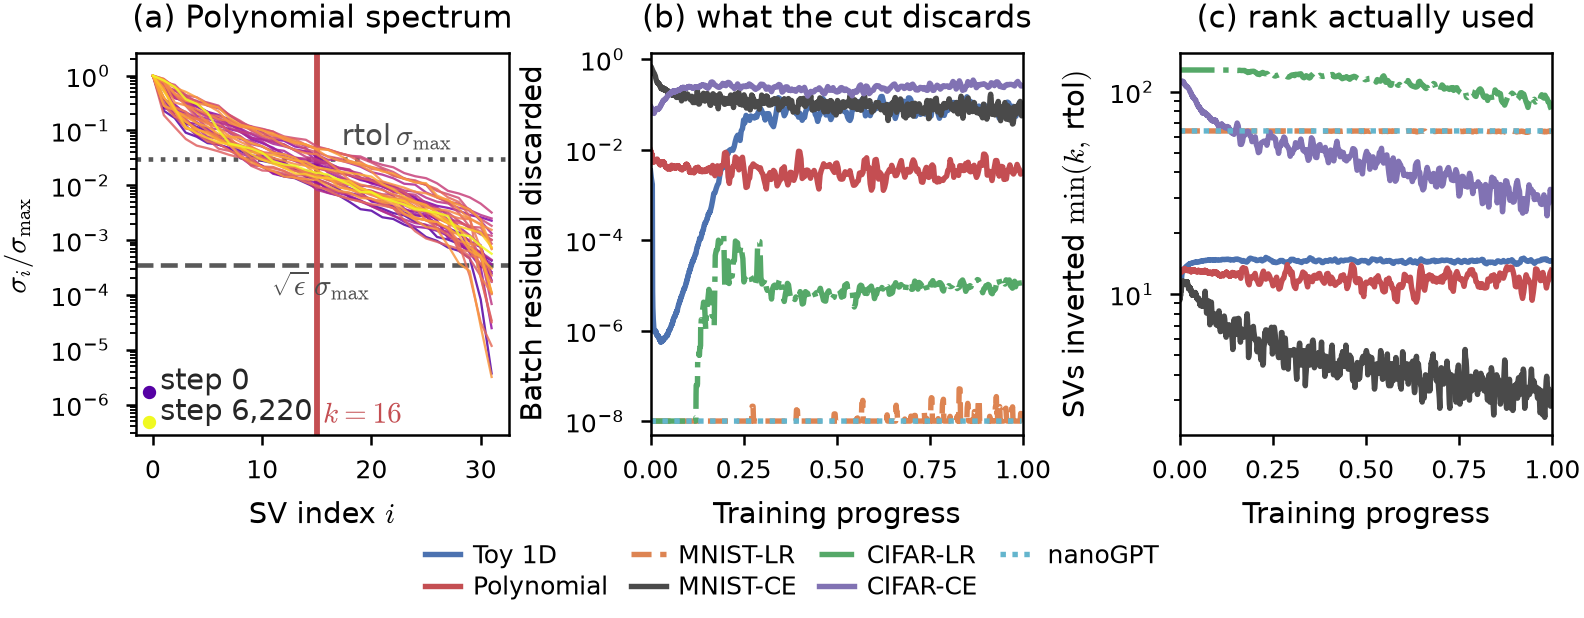

spectrum_truncation: 5.28 x 2.06 in on the page (shown at 2x)


In [24]:
f = pf.make('spectrum_truncation')
f.show(zoom=2)

In [25]:
# --- edit spectrum_truncation -------------------------------------------------------
# its own knobs: annotate_steps, aspect, cmap, discard_floor, extra_h, fraction, legend_kw, legend_ncol, limit, lw, ncol, scan_lw, scans, sharex, sharey, show_k, show_legend, show_noise, show_rtol, smooth, spectrum_headroom, spectrum_scan
# f = pf.make('spectrum_truncation', annotate_steps=True, aspect=1.0, cmap='plasma')
# f = pf.make('spectrum_truncation', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('spectrum_truncation', aspect=0.95)              # ... and make the CLI agree

## `used_rank_grid`

F9, App. O: which cut binds over the tuning (k, rtol) grid, per scan

Its own knobs:

* `aspect` — default `1.05`
* `cell_fontsize` — default `5.0`
* `cmap` — default `'viridis'`
* `extra_h` — default `0.0`
* `fraction` — default `0.33`
* `mark_selected` — default `True`
* `ncol` — default `3`
* `scans` — default `[]`
* `sharex` — default `False`
* `sharey` — default `False`


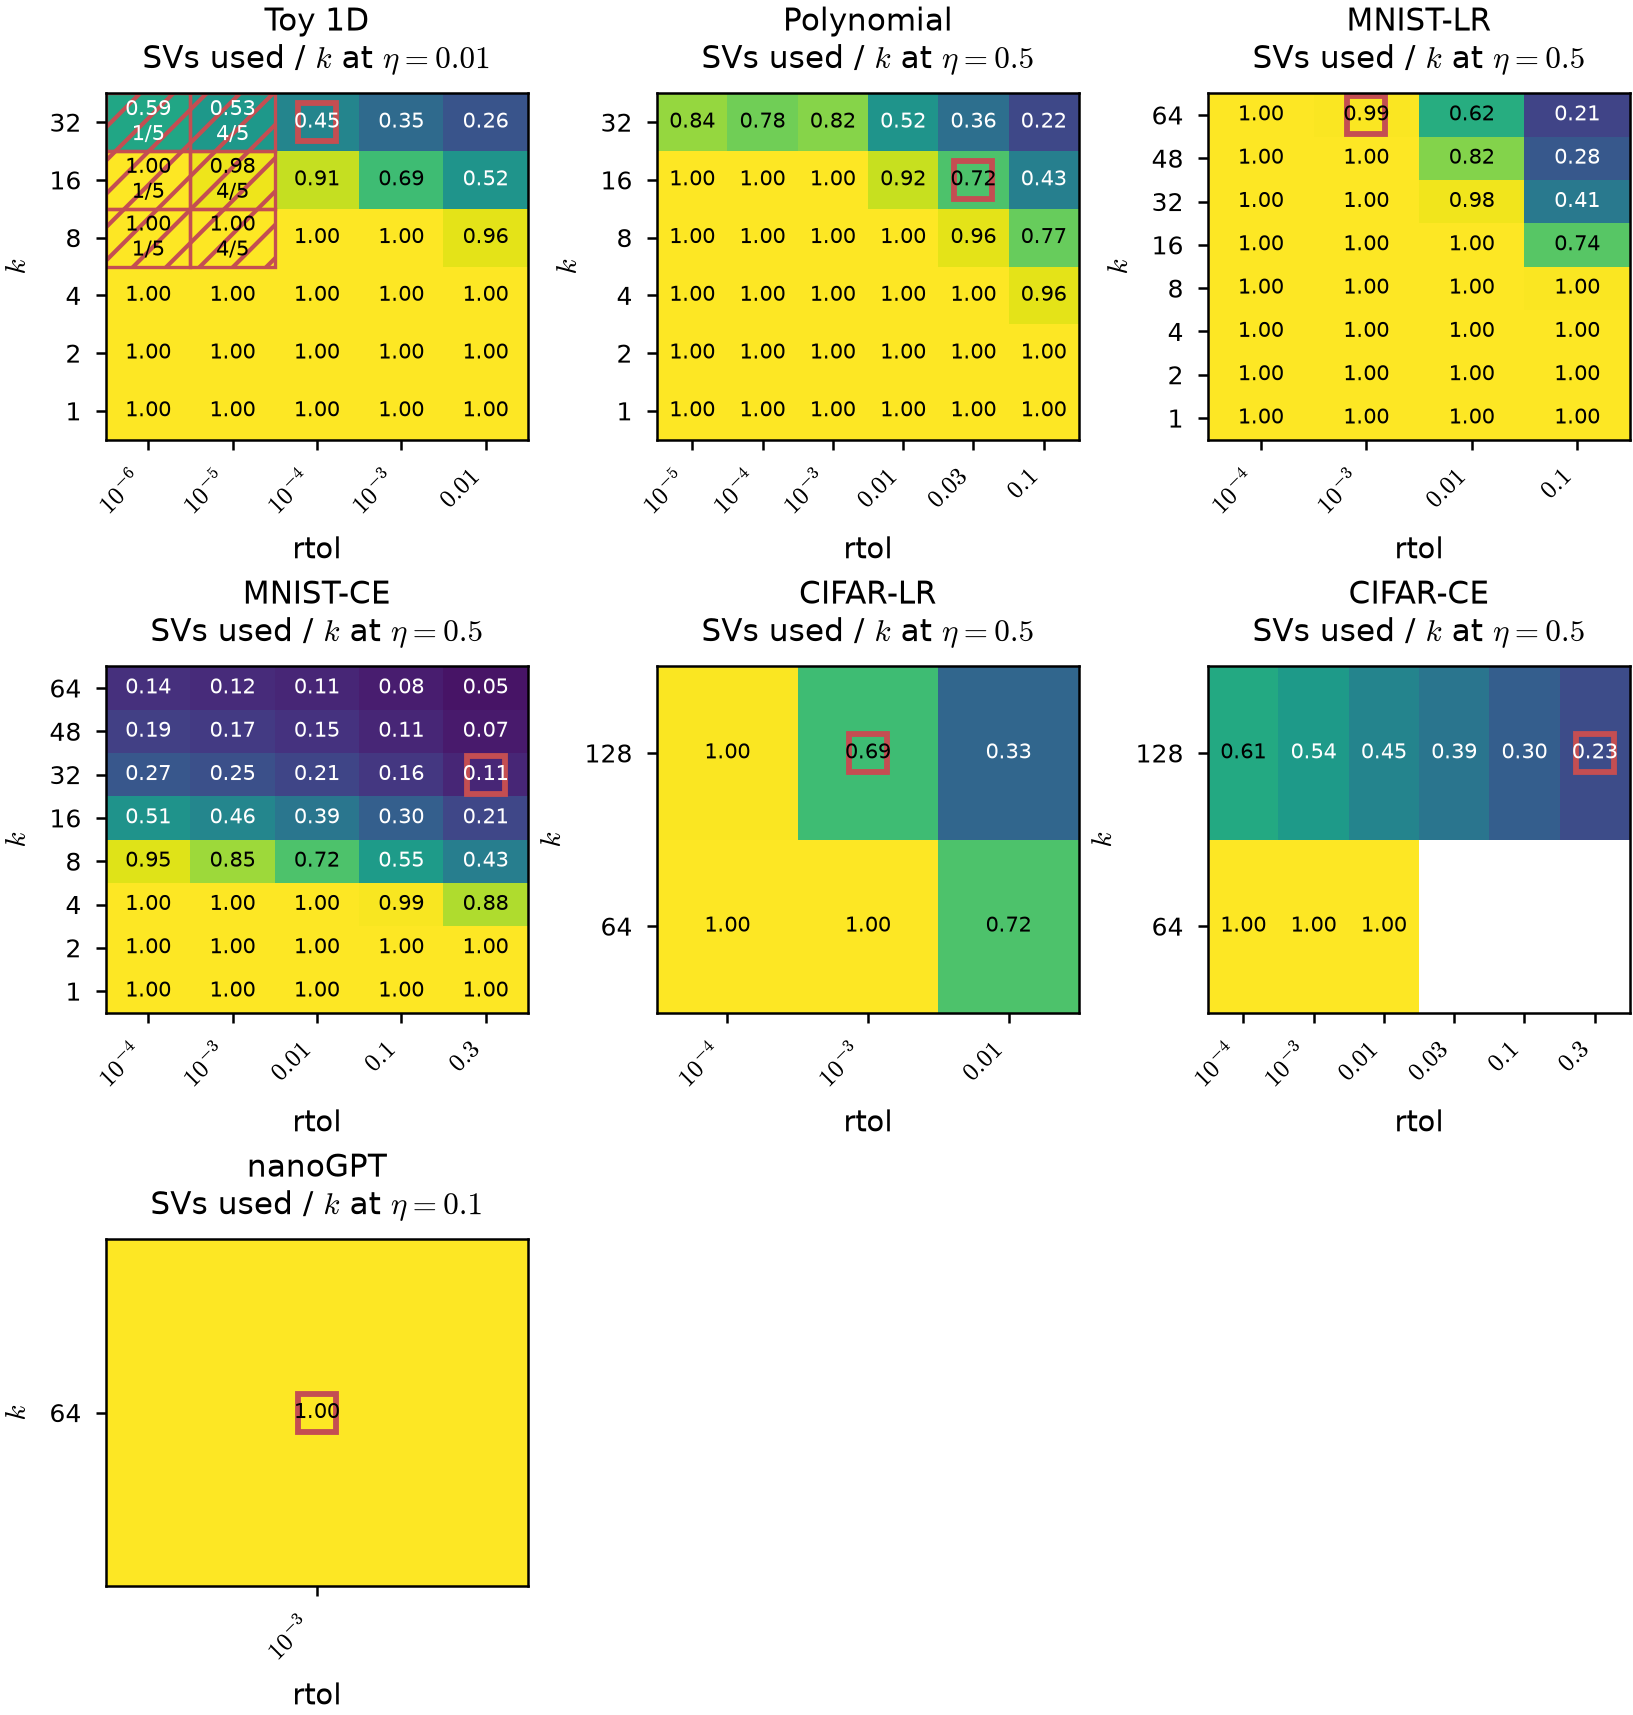

used_rank_grid: 5.45 x 5.72 in on the page (shown at 2x)


In [26]:
f = pf.make('used_rank_grid')
f.show(zoom=2)

In [27]:
# --- edit used_rank_grid -------------------------------------------------------
# its own knobs: aspect, cell_fontsize, cmap, extra_h, fraction, mark_selected, ncol, scans, sharex, sharey
# f = pf.make('used_rank_grid', aspect=1.05, cell_fontsize=5.0, cmap='viridis')
# f = pf.make('used_rank_grid', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('used_rank_grid', aspect=0.95)              # ... and make the CLI agree

## What is pinned

Everything this notebook has pinned, i.e. what `python -m paper_assets` will replay. `pf.unpin(<name>)` drops one, `pf.unpin()` drops them all.

In [28]:
pf.pinned()

{}